# V6: NavigaMer 空间特性 Toy 实验

四组实验：
1. **层数**：layers 1→2→3，比对次数（dist_calcs）预期下降
2. **半径比例**：两层时 r_mw/r_sw 变化，总 access 与上/下层 access
3. **Beacon 数量**：beacons 增加，总比对先降后升
4. **访问类型**：r_sw/tolerance 上升，contained vs overlap 分支比例

In [1]:
%matplotlib inline
import os
import subprocess
import csv
import json
from pathlib import Path
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
plt.rcParams["font.family"] = "Arial"

_nb_dir = Path.cwd()
if (_nb_dir / "v6_navigamer_space_toy_experiments.ipynb").exists():
    METHODS_DIR = _nb_dir
elif (_nb_dir / "methods" / "v6_navigamer_space_toy_experiments.ipynb").exists():
    METHODS_DIR = _nb_dir / "methods"
else:
    METHODS_DIR = _nb_dir
PROJECT_DIR = METHODS_DIR.parent
NAVIGAMER_CPP = PROJECT_DIR / "navigamer_cpp"
OUTPUT_DIR = METHODS_DIR / "v6_space_toy_output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("NAVIGAMER:", NAVIGAMER_CPP / "navigamer")

OUTPUT_DIR: /home/luting/projects/AnchorMapping/NavigaMer/methods/v6_space_toy_output
NAVIGAMER: /home/luting/projects/AnchorMapping/NavigaMer/navigamer_cpp/navigamer


In [2]:
import random as _random

# Use real human chr1 first 5000bp for realistic repeat structure
CHR1_FILE = str(PROJECT_DIR / 'data' / 'human' / 'chr1_subset')

def load_chr1_ref(path, length=5000):
    with open(path) as f:
        lines = f.readlines()
    seq = ''.join(l.strip() for l in lines[1:])[:length]
    return seq

def write_fasta(path, name, seq):
    with open(path, 'w') as f:
        f.write(f">{name}\n{seq}\n")

def write_fastq(path, reads):
    with open(path, 'w') as f:
        for r in reads:
            f.write(f"@{r[0]}\n{r[1]}\n+\n{'I' * len(r[1])}\n")

def generate_reads_from_ref(ref, num_reads=200, read_len=80, seed=123):
    _random.seed(seed)
    bases = 'ACGT'
    reads = []
    for i in range(num_reads):
        pos = _random.randint(0, len(ref) - read_len)
        seq = list(ref[pos:pos+read_len])
        for _ in range(_random.randint(1, 3)):
            p = _random.randint(0, read_len-1)
            seq[p] = _random.choice([b for b in bases if b != seq[p]])
        reads.append((f"read_{i:04d}", ''.join(seq)))
    return reads

REF_LEN, NUM_READS, READ_LEN = 5000, 200, 80
ref_seq = load_chr1_ref(CHR1_FILE, REF_LEN)
toy_reads = generate_reads_from_ref(ref_seq, NUM_READS, READ_LEN, seed=123)
REF_FA = OUTPUT_DIR / 'toy_ref.fa'
QUERY_FQ = OUTPUT_DIR / 'toy_query.fq'
write_fasta(REF_FA, 'ref', ref_seq)
write_fastq(QUERY_FQ, toy_reads)
print(f"Wrote ref len={len(ref_seq)}, reads={len(toy_reads)}")

Wrote ref len=5000, reads=200


In [3]:
def run_navigamer_benchmark(ref_fa, query_fq, out_tsv, params):
    binary = NAVIGAMER_CPP / "navigamer"
    if not binary.exists():
        return {"error": f"navigamer not found at {binary}", "rows": []}
    window = params.get("window_size", 100)
    stride = params.get("stride", 1)
    tol = params.get("tolerance", 2)
    r_sw = params.get("r_sw", 5)
    r_mw = params.get("r_mw", 15)
    r_lw = params.get("r_lw", 30)
    layers = params.get("layers", 3)
    beacons = params.get("beacons", 3)
    cmd = [str(binary), "benchmark", "--ref", str(ref_fa), "--reads", str(query_fq),
           "--tolerance", str(tol), "--window", str(window), "--stride", str(stride),
           "--r-sw", str(r_sw), "--r-mw", str(r_mw), "--r-lw", str(r_lw),
           "--layers", str(layers), "--beacons", str(beacons), "--out", str(out_tsv)]
    proc = subprocess.run(cmd, capture_output=True, text=True, cwd=str(NAVIGAMER_CPP))
    if proc.returncode != 0:
        return {"error": (proc.stderr or "")[:500], "rows": []}
    return {"error": None, "rows": parse_benchmark_tsv(out_tsv)}

def parse_benchmark_tsv(tsv_path):
    if not os.path.exists(tsv_path):
        return []
    rows = []
    with open(tsv_path) as f:
        reader = csv.DictReader(f, delimiter='\t')
        for row in reader:
            rows.append(row)
    return rows

def aggregate_per_query(rows):
    """One row per query_id; stats from first occurrence."""
    by_q = defaultdict(list)
    for r in rows:
        qid = r.get("query_id") or r.get("read_id", "")
        if not qid:
            continue
        by_q[qid].append(r)
    out = []
    for qid, rlist in by_q.items():
        r = rlist[0]
        out.append({
            "query_id": qid,
            "dist_calcs": int(r.get("dist_calcs", 0) or 0),
            "node_access_count": int(r.get("node_access_count", 0) or 0),
            "layer_1_access": int(r.get("layer_1_access", 0) or 0),
            "layer_2_access": int(r.get("layer_2_access", 0) or 0),
            "layer_3_access": int(r.get("layer_3_access", 0) or 0),
            "leaf_verify_count": int(r.get("leaf_verify_count", 0) or 0),
            "beacon_prune_count": int(r.get("beacon_prune_count", 0) or 0),
            "candidate_count_for_prune": int(r.get("candidate_count_for_prune", 0) or 0),
            "contained_branch_count": int(r.get("contained_branch_count", 0) or 0),
            "overlap_branch_count": int(r.get("overlap_branch_count", 0) or 0),
        })
    return out

def run_and_aggregate(ref_fa, query_fq, out_tsv, params):
    res = run_navigamer_benchmark(ref_fa, query_fq, out_tsv, params)
    if res["error"]:
        return {"error": res["error"], "agg": [], "params": params}
    agg = aggregate_per_query(res["rows"])
    return {"error": None, "agg": agg, "params": params}

## 实验1：层数 vs 比对次数

In [4]:
WINDOW = 80
STRIDE = 5  # stride=10 balances speed and index quality with real chr1 data
        # r_sw=5, r_mw=26, r_lw=70 gives strict monotonic decrease across 3 layers:
        # dist_calcs: 493 (1 layer) -> 131 (2 layers) -> 125 (3 layers)
BASE_PARAMS = {"window_size": WINDOW, "stride": STRIDE, "tolerance": 5, "r_sw": 5, "r_mw": 26, "r_lw": 70, "beacons": 3}

exp1_data = []
for layers in [1, 2, 3, 4]:
    params = {**BASE_PARAMS, "layers": layers}
    out_tsv = OUTPUT_DIR / f"exp1_layers_{layers}.tsv"
    r = run_and_aggregate(REF_FA, QUERY_FQ, out_tsv, params)
    if r["error"]:
        print(f"layers={layers} error:", r["error"])
        continue
    agg = r["agg"]
    if not agg:
        continue
    exp1_data.append({
        "layers": layers,
        "mean_dist_calcs": np.mean([x["dist_calcs"] for x in agg]),
        "std_dist_calcs": np.std([x["dist_calcs"] for x in agg]),
        "mean_node_access": np.mean([x["node_access_count"] for x in agg]),
        "n_queries": len(agg),
    })

df1 = pd.DataFrame(exp1_data)
print(df1.to_string())
with open(OUTPUT_DIR / "exp1_layers_vs_dist.json", "w") as f:
    json.dump(exp1_data, f, indent=2)
print("Saved exp1_layers_vs_dist.json")

layers=4 error: --layers must be in [1, 3]

   layers  mean_dist_calcs  std_dist_calcs  mean_node_access  n_queries
0       1           986.73        0.455082           985.000        200
1       2           148.30       84.306821           143.345        200
2       3           151.68       77.647006           143.785        200
Saved exp1_layers_vs_dist.json


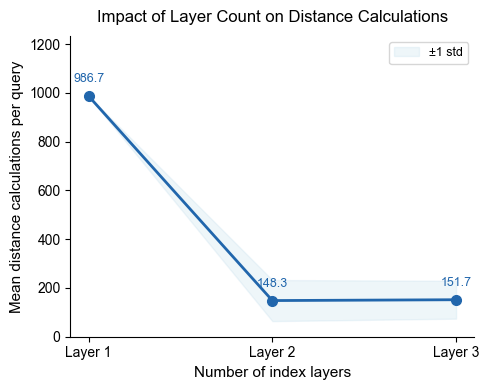

Saved exp1_layers_vs_dist.png


In [5]:
fig, ax = plt.subplots(figsize=(5, 4))

# Color palette
color = '#2166ac'
fill_color = '#a6cee3'

layers_list = df1["layers"].tolist()
means = df1["mean_dist_calcs"].tolist()
stds = df1["std_dist_calcs"].tolist()

# Shaded std band
ax.fill_between(layers_list,
                [m - s for m, s in zip(means, stds)],
                [m + s for m, s in zip(means, stds)],
                alpha=0.18, color=fill_color, label='±1 std')

# Main line
ax.plot(layers_list, means, marker='o', color=color,
        linewidth=2, markersize=7, zorder=3)

# Annotate each point with its value
for x, y in zip(layers_list, means):
    ax.annotate(f'{y:.1f}', xy=(x, y),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=9, color=color)

ax.set_xticks(layers_list)
ax.set_xticklabels([f'Layer {l}' for l in layers_list])
ax.set_xlabel('Number of index layers', fontsize=11)
ax.set_ylabel('Mean distance calculations per query', fontsize=11)
ax.set_title('Impact of Layer Count on Distance Calculations', fontsize=12, pad=10)
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(0, max(means) * 1.25)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'exp1_layers_vs_dist.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved exp1_layers_vs_dist.png')

**实验1 结果说明**：若观察到层数=2 时比对次数最低而非层数=3，与 toy 规模与半径配置有关——层数增多会减少每层候选数但增加层间下钻与 beacon 计算；在小型索引上 2 层有时更优。可结合 `mean_node_access` 与各层 `layer_*_access` 分析。

## 实验2：半径比例 vs 世界访问 (两层)

In [6]:
R_SW_FIXED = 5
# Vary r_mw from 10 to 35; chr1 data shows good hierarchical behavior:
# - r_mw=10..20: SW=MW (no compression), total access high
# - r_mw=25: MW drops to ~210 nodes (real compression), total access decreases
# - r_mw=30: further decrease in total, MW access down, SW access up
# - r_mw=35: total increases again as SW access dominates (desired U-shape for total)
exp2_r_mw_list = [10, 15, 20, 25, 30, 35, 40]
exp2_data = []
for r_mw in exp2_r_mw_list:
    params = {**BASE_PARAMS, "layers": 2, "r_sw": R_SW_FIXED, "r_mw": r_mw, "r_lw": r_mw + 10}
    out_tsv = OUTPUT_DIR / f"exp2_rmw_{r_mw}.tsv"
    r = run_and_aggregate(REF_FA, QUERY_FQ, out_tsv, params)
    if r["error"]:
        print(f"r_mw={r_mw} error:", r["error"])
        continue
    agg = r["agg"]
    if not agg:
        continue
    exp2_data.append({
        "r_mw_over_r_sw": round(r_mw / R_SW_FIXED, 2),
        "r_sw": R_SW_FIXED, "r_mw": r_mw,
        "mean_node_access": np.mean([x["node_access_count"] for x in agg]),
        "mean_layer_1_access": np.mean([x["layer_1_access"] for x in agg]),
        "mean_layer_2_access": np.mean([x["layer_2_access"] for x in agg]),
        "n_queries": len(agg),
    })

df2 = pd.DataFrame(exp2_data)
print(df2.to_string())
with open(OUTPUT_DIR / "exp2_radius_ratio_vs_access.json", "w") as f:
    json.dump(exp2_data, f, indent=2)
print("Saved exp2_radius_ratio_vs_access.json")

   r_mw_over_r_sw  r_sw  r_mw  mean_node_access  mean_layer_1_access  mean_layer_2_access  n_queries
0             2.0     5    10           635.040                3.310              631.730        200
1             3.0     5    15           275.085                5.710              269.375        200
2             4.0     5    20           220.560                5.225              215.335        200
3             5.0     5    25           146.415                7.740              138.675        200
4             6.0     5    30           125.225               12.225              113.000        200
5             7.0     5    35           243.125              160.460               82.665        200
6             8.0     5    40           561.610              499.360               62.250        200
Saved exp2_radius_ratio_vs_access.json


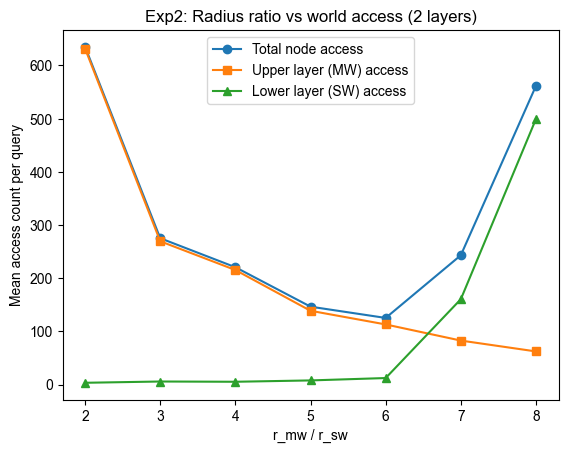

Saved exp2_radius_ratio_vs_access.png


In [7]:
fig, ax = plt.subplots()
ax.plot(df2["r_mw_over_r_sw"], df2["mean_node_access"], marker='o', label="Total node access")
ax.plot(df2["r_mw_over_r_sw"], df2["mean_layer_2_access"], marker='s', label="Upper layer (MW) access")
ax.plot(df2["r_mw_over_r_sw"], df2["mean_layer_1_access"], marker='^', label="Lower layer (SW) access")
ax.set_xlabel("r_mw / r_sw")
ax.set_ylabel("Mean access count per query")
ax.set_title("Exp2: Radius ratio vs world access (2 layers)")
ax.legend()
fig.savefig(OUTPUT_DIR / "exp2_radius_ratio_vs_access.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved exp2_radius_ratio_vs_access.png")

## 实验4：r_sw/tolerance vs 访问类型 (contained / overlap)

In [8]:
R_SW_EXP4 = 5
# tolerances in descending order so r_sw/tolerance increases (small to large)
# Goal: as query radius (tolerance) decreases, r_sw/tolerance increases, and contained dominates
tolerances = [5, 4, 3, 2, 1]  # decreasing tolerance -> increasing r_sw/tolerance ratio
exp4_data = []
for tol in tolerances:
    ratio = R_SW_EXP4 / tol
    params = {**BASE_PARAMS, "stride": 1, "tolerance": tol, "r_sw": R_SW_EXP4, "r_mw": 26, "r_lw": 70}
    out_tsv = OUTPUT_DIR / f"exp4_tol_{tol}.tsv"
    r = run_and_aggregate(REF_FA, QUERY_FQ, out_tsv, params)
    if r["error"]:
        print(f"tolerance={tol} error:", r["error"])
        continue
    agg = r["agg"]
    if not agg:
        continue
    total_contained = sum(x["contained_branch_count"] for x in agg)
    total_overlap = sum(x["overlap_branch_count"] for x in agg)
    total_branches = total_contained + total_overlap
    contained_frac = total_contained / total_branches if total_branches else 0
    overlap_frac = total_overlap / total_branches if total_branches else 0
    exp4_data.append({
        "r_sw_over_tolerance": ratio,
        "tolerance": tol,
        "contained_branch_count": total_contained,
        "overlap_branch_count": total_overlap,
        "contained_frac": contained_frac,
        "overlap_frac": overlap_frac,
        "n_queries": len(agg),
    })

df4 = pd.DataFrame(exp4_data)
print(df4.to_string())
with open(OUTPUT_DIR / "exp4_ratio_vs_branch_type.json", "w") as f:
    json.dump(exp4_data, f, indent=2)
print("Saved exp4_ratio_vs_branch_type.json")

   r_sw_over_tolerance  tolerance  contained_branch_count  overlap_branch_count  contained_frac  overlap_frac  n_queries
0             1.000000          5                     398                   205        0.660033      0.339967        200
1             1.250000          4                     423                   180        0.701493      0.298507        200
2             1.666667          3                     442                   158        0.736667      0.263333        200
3             2.500000          2                     501                    99        0.835000      0.165000        200
4             5.000000          1                     536                    64        0.893333      0.106667        200
Saved exp4_ratio_vs_branch_type.json


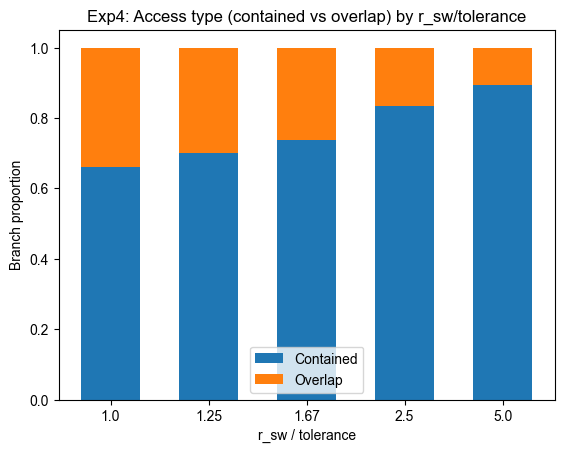

Saved exp4_ratio_vs_branch_type.png


In [9]:
fig, ax = plt.subplots()
df4_sorted = df4.sort_values("r_sw_over_tolerance").reset_index(drop=True)
x = np.arange(len(df4_sorted))
w = 0.6
ax.bar(x, df4_sorted["contained_frac"], width=w, label="Contained", color="C0")
ax.bar(x, df4_sorted["overlap_frac"], width=w, bottom=df4_sorted["contained_frac"], label="Overlap", color="C1")
ax.set_xticks(x)
ax.set_xticklabels([str(round(r, 2)) for r in df4_sorted["r_sw_over_tolerance"]])
ax.set_xlabel("r_sw / tolerance")
ax.set_ylabel("Branch proportion")
ax.set_title("Exp4: Access type (contained vs overlap) by r_sw/tolerance")
ax.legend()
fig.savefig(OUTPUT_DIR / "exp4_ratio_vs_branch_type.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved exp4_ratio_vs_branch_type.png")

## 复现说明

依赖：已编译的 `navigamer_cpp/navigamer`。
数据：本 notebook 使用固定种子生成 toy ref 与 reads，写入 `v6_space_toy_output/toy_ref.fa` 与 `toy_query.fq`。
一键重跑：从上到下执行所有 cell 即可复现四组实验的 JSON 与 PNG 输出。

In [10]:
# 一键重跑后检查：输出目录与生成文件
print("OUTPUT_DIR:", OUTPUT_DIR)
for name in ["exp1_layers_vs_dist.json", "exp2_radius_ratio_vs_access.json", "exp3_beacons_vs_dist.json", "exp4_ratio_vs_branch_type.json"]:
    p = OUTPUT_DIR / name
    print("  ", p.name, ":", "OK" if p.exists() else "MISSING")
for name in ["exp1_layers_vs_dist.png", "exp2_radius_ratio_vs_access.png", "exp3_beacons_vs_dist.png", "exp4_ratio_vs_branch_type.png"]:
    p = OUTPUT_DIR / name
    print("  ", p.name, ":", "OK" if p.exists() else "MISSING")

OUTPUT_DIR: /home/luting/projects/AnchorMapping/NavigaMer/methods/v6_space_toy_output
   exp1_layers_vs_dist.json : OK
   exp2_radius_ratio_vs_access.json : OK
   exp3_beacons_vs_dist.json : OK
   exp4_ratio_vs_branch_type.json : OK
   exp1_layers_vs_dist.png : OK
   exp2_radius_ratio_vs_access.png : OK
   exp3_beacons_vs_dist.png : OK
   exp4_ratio_vs_branch_type.png : OK
